**Table of contents**<a id='toc0_'></a>    
- [Question 1 - Data Analysis](#toc1_)    
  - [i) Counting Examples](#toc1_1_)    
  - [ii) Protein Expression Histograms](#toc1_2_)    
  - [iii) Image Preprocessing](#toc1_3_)    
  - [iv) Channel Correlation with CD11b Expression](#toc1_4_)    
  - [v) Blue vs H Channels](#toc1_5_)    
- [Question 2](#toc2_)    
  - [i) Feature Selection](#toc2_1_)    
    - [PCA On all RGB Channels](#toc2_1_1_)    
    - [PCA on all HED channels](#toc2_1_2_)    
    - [Mean and Variance](#toc2_1_3_)    
    - [Histogram of Gradients](#toc2_1_4_)    
    - [GLCM](#toc2_1_5_)    
    - [Local Binary Pattern](#toc2_1_6_)    
  - [Regression Models](#toc2_2_)    
    - [Linear Regression](#toc2_2_1_)    
    - [Random Forest](#toc2_2_2_)    
    - [SVC](#toc2_2_3_)    
- [Question 3](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
!pip install tqdm # for progress bars
!pip install seaborn # for barplot
!pip install opencv-python # for image manipulation

ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.


ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.


ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.


# <a id='toc1_'></a>[Question 1 - Data Analysis](#toc0_)

## <a id='toc1_1_'></a>[i) Counting Examples](#toc0_)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')

df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
train_specimens = ['B1', 'C1', 'D1']
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']

Let's first separate the training and test data. 

In [3]:
df_train = df.loc[df['specimen_id'].isin(train_specimens)]
df_test = df.loc[df['specimen_id'] == 'A1']

df_train['CD11b'].describe()

count    7027.000000
mean       -1.584007
std         1.481296
min        -4.782092
25%        -2.794762
50%        -1.180678
75%        -0.321114
max         1.761779
Name: CD11b, dtype: float64

The number of spots of each specimen in the training set are given below:

In [4]:
df_train.groupby('specimen_id')['specimen_id'].value_counts()

specimen_id
B1    1145
C1    4129
D1    1753
Name: count, dtype: int64

## <a id='toc1_2_'></a>[ii) Protein Expression Histograms](#toc0_)

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

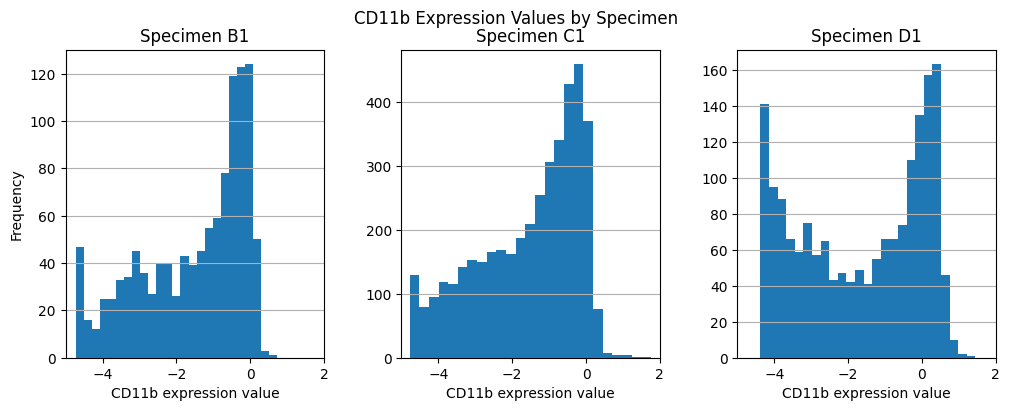

In [5]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=25)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')


We notice that specimen B1 and C1 have similar distributions of the expression value of protein CD11b, with peaks at around 0 and tails to the left down to -5. Specimen D1 has two peaks at -4 and 0. 

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

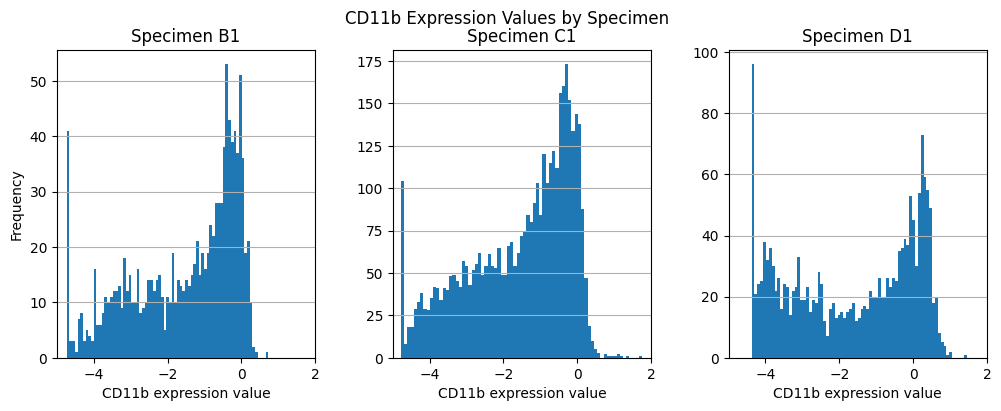

In [6]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=75)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')

If we plot using more bins, we also notice that all three specimen have a peak at a very specific value on the left. This is interesting because there appear to be no expression values to the left of these peaks. 

In [7]:
df_train[['specimen_id', 'CD11b']].value_counts()

specimen_id  CD11b    
C1           -4.782092    104
D1           -4.376121     90
B1           -4.731601     40
C1           -4.402024      2
             -0.155368      1
                         ... 
             -2.256882      1
             -2.259379      1
             -2.261223      1
             -2.261946      1
             -2.240232      1
Name: count, Length: 6795, dtype: int64

We can see the peaks in the above value counts. The frequency peaks are at very specific values, whereas all (except one) other values have a frequency of 1. Plus, there are no values below the peaks. One possible explanation for this suggests that maybe originally there were values below the peaks, but they were for some reason all grouped into that one peak value. 

## <a id='toc1_3_'></a>[iii) Image Preprocessing](#toc0_)

In [8]:
image_folder = '/content/patches_256/'
from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgba2rgb, rgb2hed
from skimage.io import imread
from skimage.util import img_as_ubyte
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import os
import glob

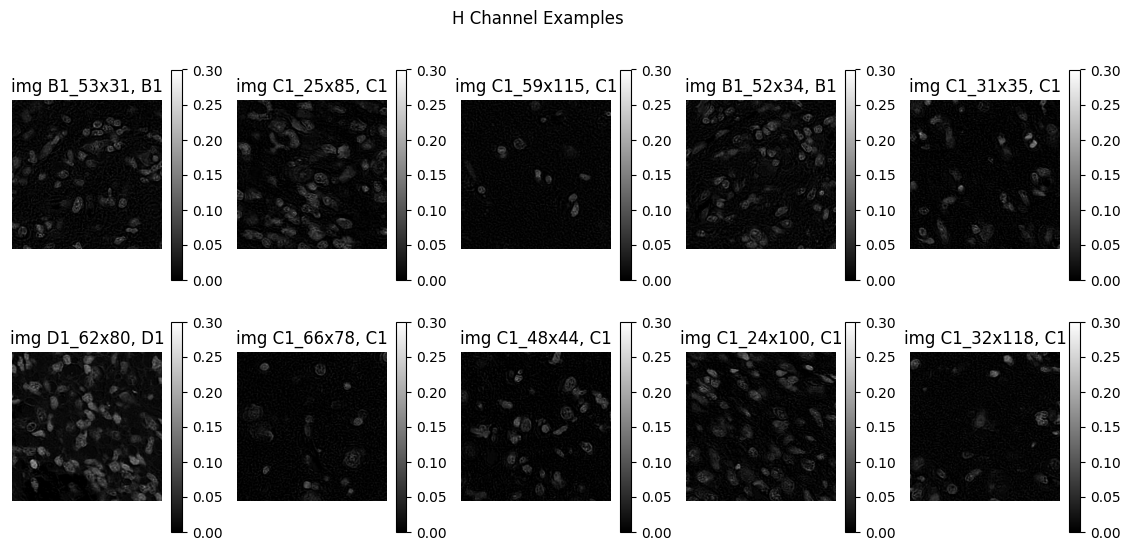

In [9]:

plt.figure(figsize=[14, 6])
for i, im_id in enumerate(np.random.choice(df_train.index, size=10, replace=False)):
    row = df_train.loc[im_id]
    path = os.getcwd()+image_folder+im_id + '.png'
    I = imread(path)
    if I.shape[2] == 4: # It's an RGBA image
        I = rgba2rgb(I)
    I_hed = rgb2hed(I)
    I_h = I_hed[:,:,0]; 
    plt.subplot(2, 5, i+1)
    plt.imshow(I_h,cmap='gray', vmin=0,vmax=0.3);  
    plt.colorbar();  
    plt.title(f'img {im_id}, {row['specimen_id']}')
    plt.axis('off')
plt.suptitle('H Channel Examples')
plt.show()

## <a id='toc1_4_'></a>[iv) Channel Correlation with CD11b Expression](#toc0_)

In [ ]:
from tqdm.notebook import tqdm, trange

def images_from_ids(im_ids):
    imgs = []
    for im_id in tqdm(im_ids):
        path = os.getcwd()+image_folder+im_id+'.png'
        I = plt.imread(path)
        if I.shape[2] == 4: # it's an RGBA image 
            I = rgba2rgb(I)
        imgs.append(I)
    return np.array(imgs)     

def images_to_HED(X): 
    X_HED = np.zeros_like(X)
    for i in range(X.shape[0]):
        X_HED[i] = rgb2hed(X[i])
    return X_HED

X_train = images_from_ids(df_train.index)
y_train = df_train['CD11b']
print("Loading testing images")
X_test = images_from_ids(df_test.index)
y_test = df_test['CD11b']   

X_HED_train = images_to_HED(X_train)
X_HED_test = images_to_HED(X_test)

In [ ]:
average_hs = np.mean(X_HED_train[..., 0], axis=(1, 2))
average_bs = np.mean(X_train[..., 2], axis=(1, 2))
average_es = np.mean(X_HED_train[..., 1], axis=(1, 2))
cd11b_values = df_train['CD11b']

b_indices = np.where(df_train['specimen_id'] == 'B1')[0]
c_indices = np.where(df_train['specimen_id'] == 'C1')[0]
d_indices = np.where(df_train['specimen_id'] == 'D1')[0]

print(f"Average H: {np.mean(average_hs)}")
print(f"Average Blue: {np.mean(average_bs)}")
print(f"Average E: {np.mean(average_es)}")

In [ ]:

plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], cd11b_values.iloc[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], cd11b_values.iloc[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], cd11b_values.iloc[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average H Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')


print(f"Spearman correlation of average H channel with CD11b: {spearmanr(average_hs, cd11b_values).statistic}")
print(f"Pearson correlation of average H channel with CD11b: {pearsonr(average_hs, cd11b_values).statistic}")

There is a very weak negative correlation between the H-channel intensity and the CD11b expression. H-channel intensity is unlikely to have much predictive power for CD11b expression. It explains very little variance in the expression. What we do notice is that each of the three specimen have some separability based on the H-channel. This is significant as it suggests that the test specimen (A1) may also have a different H-channel intensity from the rest. This may indicate that when training models, we need to create our validation sets based on specimen, as this will allow us to evaluate how well our models are able to generalise to different specimens. 

In [ ]:
plt.figure()
ax = plt.gca()

ax.scatter(average_es[b_indices], cd11b_values.iloc[b_indices], s=3, label='Specimen B1')
ax.scatter(average_es[c_indices], cd11b_values.iloc[c_indices], s=3, label='Specimen C1')
ax.scatter(average_es[d_indices], cd11b_values.iloc[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average E channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average E Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(f"Spearman correlation of average E channel with CD11b: {spearmanr(average_es, cd11b_values).statistic}")
print(f"Pearson correlation of average E channel with CD11b: {pearsonr(average_es, cd11b_values).statistic}")

There is a weak, but stronger, positive correlation between the E channel and the CD11b expression value. The E channel average may help to predict the CD11b expression. However, there is still a lot of unexplained variance. 

In [ ]:
plt.figure()
ax = plt.gca()

ax.scatter(average_bs[b_indices], cd11b_values.iloc[b_indices], s=3, label='Specimen B1')
ax.scatter(average_bs[c_indices], cd11b_values.iloc[c_indices], s=3, label='Specimen C1')
ax.scatter(average_bs[d_indices], cd11b_values.iloc[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average Blue channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average Blue Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(f"Spearman correlation of average blue channel with CD11b: {spearmanr(average_bs, cd11b_values).statistic}")
print(f"Pearson correlation of average blue channel with CD11b: {pearsonr(average_bs, cd11b_values).statistic}")



## <a id='toc1_5_'></a>[v) Blue vs H Channels](#toc0_)

In [ ]:
plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], average_bs[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], average_bs[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], average_bs[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('Average Blue channel intensity')
ax.set_title('Average H vs Average Blue channel intensities', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(spearmanr(average_hs, average_bs).statistic)
print(pearsonr(average_hs, average_bs).statistic)

We can see that the H channel is able to partially separate out the three specimens, whereas the blue channel is much less able to do this. We can also see that there is some correlation between the H and Blue channels, but it is highly non-linear, which is due to the fact that the H channel is also influenced by the red and green channels. However, we can see that there are limits as to what blue values can be converted to what H values, and the shape roughly appears triangular in the scatter diagram. For example, there are no examples where an average blue channel of 0.9 correlates to an average H channel of 0.03. 

We can check for association between protein expression levels by finding the pairwise correlations of each. You can see the result below, with red colours indicating a higher correlation between the proteins. It is evident that there is association between protein expression levels of some pairs of proteins. For example, MET and PDGFRa are quite positively correlated. In fact, the correlations are mostly positvie. There are some pairs that are weakly negatively correlated. 

Most significantly, however, we notice that values of H are in general **much lower** (ranging from 0 to 0.04) than values of blue, ranging from 0.4 to 1. This indicates that feature scaling will be necessary when looking for features such as with PCA. 

In [ ]:
corr = df_train[protein_names].corr()

plt.figure(figsize=[9, 8])
ax = plt.gca()
corr_ax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(corr_ax)
ticks = np.arange(0, len(protein_names))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(protein_names, fontsize=7, rotation=90)
ax.set_yticklabels(protein_names, fontsize=7);

# <a id='toc2_'></a>[Question 2](#toc0_)

## <a id='toc2_1_'></a>[i) Feature Selection](#toc0_)

### <a id='toc2_1_1_'></a>[PCA On all RGB Channels](#toc0_)

For all the feature selection questions, we're going to downsample the images to 128x128 pixels (from 256x256), to decrease compute requirements. 

In [ ]:
from sklearn.decomposition import PCA
import cv2

# Resize function
def resize_images(X, new_size=(128, 128)):
    """Resizes all images in X to new_size."""
    n_train, _, _, c = X.shape
    X_resized = np.zeros((n_train, new_size[0], new_size[1], c), dtype=X.dtype)

    for i in range(n_train):
        X_resized[i] = cv2.resize(X[i], new_size, interpolation=cv2.INTER_AREA)
    
    return X_resized

X_train = resize_images(X_train)
X_test = resize_images(X_test)
X_HED_train = resize_images(X_HED_train)
X_HED_test = resize_images(X_HED_test)

n_train, width, height, c = X_train.shape

Using the first image as an example

### <a id='toc2_1_2_'></a>[PCA on all HED channels](#toc0_)

In [ ]:
pca = PCA(10)
pcs = pca.fit_transform(X_train.reshape((X_train.shape[0]), -1))

plt.plot(np.arange(1, pca.n_components_ + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('# components')
plt.ylabel('Explained variance')
plt.ylim([0, 1])

In [ ]:
# Set number of principal components to keep
n_components = 10  # Change this to any desired number of PCs

# Function to scale each channel separately
def scale_all_channels(X):
    """Scales each image channel independently to zero mean, unit variance."""
    n_train, h, w, c = X.shape
    X_scaled = np.zeros((n_train, h*w*c))  # Reshape to [n_train, pixels, channels]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.reshape(n_train, -1))  # Scale each channel separately
    
    return X_scaled.reshape(n_train, -1)  # Flatten back into [n_train, features]

# Apply per-channel scaling
#X_rgb_scaled = scale_all_channels(X)  # Scale RGB channels independently
#X_hed_scaled = scale_all_channels(X_HED)  # Scale HED channels independently

# Scale individual channels separately before PCA
def scale_single_channel(X_channel):
    """Scales a single-channel image dataset."""
    scaler = StandardScaler()
    return scaler.fit_transform(X_channel.reshape(n_train, -1))

X_r_scaled = scale_single_channel(X_train[..., 0])
X_g_scaled = scale_single_channel(X_train[..., 1])
X_b_scaled = scale_single_channel(X_train[..., 2])
X_h_scaled = scale_single_channel(X_HED_train[..., 0])
X_e_scaled = scale_single_channel(X_HED_train[..., 1])
X_d_scaled = scale_single_channel(X_HED_train[..., 2])

# Perform PCA with a variable number of components
def apply_pca(X_flat):
    return PCA(n_components=n_components).fit_transform(X_flat)

pca_results = {
    #"RGB": apply_pca(X_rgb_scaled),
    #"HED": apply_pca(X_hed_scaled),
    "R": apply_pca(X_r_scaled),
    "G": apply_pca(X_g_scaled),
    "B": apply_pca(X_b_scaled),
    "H": apply_pca(X_h_scaled),
    "E": apply_pca(X_e_scaled),
    "D": apply_pca(X_d_scaled),
}

print(np.array(list(pca_results.values())).shape)
df_pca = pd.DataFrame(np.moveaxis(np.array(list(pca_results.values())), [0, 1, 2], [0, 2, 1]).reshape((6 * n_components, -1)).T)

def compute_pearson(pca_result):
    return [pearsonr(pca_result[:, i], df_train["CD11b"])[0] for i in range(pca_result.shape[1])]

correlations = {key: compute_pearson(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.5, vmax=0.5)
plt.title(f"Pearson Correlation of {n_components} Principal Components with CD11b Expression (Scaled Per-Channel)")
plt.show()


In [ ]:
# Compute Pearson correlation with CD11b expression
def compute_spearman(pca_result):
    return [spearmanr(pca_result[:, i], df_train["CD11b"])[0] for i in range(pca_result.shape[1])]

correlations = {key: compute_spearman(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.5, vmax=0.5)
plt.title(f"Spearman Correlation of {n_components} Principal Components with CD11b Expression")
plt.show()

We hope that the PCA components are able to capture patterns in the pixels of the images. However, the correlations given in the tables above are not promising. The first PC, which likely just captures the mean values of the pixels, is the only one with a significant correlation. 

### <a id='toc2_1_3_'></a>[Mean and Variance](#toc0_)

In [ ]:
features = {
    "mean_R": np.mean(X_train[..., 0], axis=(1, 2)),  # Mean of Red channel
    "var_R": np.var(X_train[..., 0], axis=(1, 2)),    # Variance of Red channel
    "mean_G": np.mean(X_train[..., 1], axis=(1, 2)),  # Green
    "var_G": np.var(X_train[..., 1], axis=(1, 2)),    
    "mean_B": np.mean(X_train[..., 2], axis=(1, 2)),  # Blue
    "var_B": np.var(X_train[..., 2], axis=(1, 2)),    
    "mean_H": np.mean(X_HED_train[..., 0], axis=(1, 2)),   # H
    "var_H": np.var(X_HED_train[..., 0], axis=(1, 2)),
    "mean_E": np.mean(X_HED_train[..., 1], axis=(1, 2)),   # E
    "var_E": np.var(X_HED_train[..., 1], axis=(1, 2)),
    "mean_D": np.mean(X_HED_train[..., 2], axis=(1, 2)),   # D
    "var_D": np.var(X_HED_train[..., 2], axis=(1, 2)),
}

# Convert to DataFrame
df_mean_var = pd.DataFrame(features)

# Compute Pearson correlation with CD11b
pearson_corr = df_mean_var.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_mean_var.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine both Pearson and Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Reshape to table format (transpose for better readability)
df_corr_table = df_corr.T

# Plot heatmap
color_scale = 0.5  # Adjust for better visualization
plt.figure(figsize=(10, 2))
sns.heatmap(df_corr_table, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Pearson & Spearman Correlation of Mean/Variance Features with CD11b Expression")
plt.show()

If we compare the correlation values of the mean of each channel with the first PCA component for the respective channels, the values seem to be very similar (if not the same). The variance values also exhibit some correlation. Therefore it's probably wise to exclude the PCs from the final set of features, as the only PC with a high correlation is made redundant by the mean values. 

### <a id='toc2_1_4_'></a>[Histogram of Gradients](#toc0_)

Histogram of Oriented Gradients (HoG) is useful for capturing local gradient orientation information. The hope is that it will be able to identify useful shapes and textures in the spots. 

In [ ]:
# Parameters for HOG
hog_params = {
    "orientations": 9,     
    "pixels_per_cell": (16, 16),  
    "cells_per_block": (2, 2),  # for normalisation
    "feature_vector": True  # flatten features
}

# Compute HOG features for each image
hog_features = []
for img in X_train:
    gray_img = rgb2gray(img)  # Convert RGB to grayscale
    hog_vector = hog(gray_img, **hog_params)  # Compute HOG
    hog_features.append(hog_vector)

# Convert to DataFrame
df_hog = pd.DataFrame(hog_features)

# Compute Pearson and Spearman correlations
pearson_corr = df_hog.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_hog.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine Pearson & Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Select top 10 most correlated (absolute values)
df_corr["Max Abs Corr"] = df_corr.abs().max(axis=1)
df_corr_top10 = df_corr.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Plot heatmap
plt.figure(figsize=(10, 2))
sns.heatmap(df_corr_top10.T, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Top 10 Correlated HOG Features with CD11b Expression")
plt.show()

### <a id='toc2_1_5_'></a>[GLCM](#toc0_)

GLCM looks at the direction and distance between pairs of images and quantifies how often we can find pairs of intensities at these values. It may be useful for detecting smoothness and contrast in and between cells. 

In [ ]:
# Parameters for GLCM
glcm_params = {
    "distances": [1, 2, 3, 5] ,     # Pixel displacements
    "angles": np.pi/4 * np.arange(4)  # Angles
}

# Compute HOG features for each image
glcm_features = []
for img in X_train:
    gray_img = rgb2gray(img)  # Convert RGB to grayscale
    glcm = graycomatrix((255 * gray_img).astype(np.uint8), **glcm_params) 
    glcm_vector = []
    glcm_vector.append(graycoprops(glcm, 'contrast'))
    glcm_vector.append(graycoprops(glcm, 'dissimilarity'))
    glcm_vector.append(graycoprops(glcm, 'homogeneity'))
    glcm_vector.append(graycoprops(glcm, 'energy'))
    glcm_vector.append(graycoprops(glcm, 'correlation'))
    glcm_features.append(np.array(glcm_vector).flatten())

# Convert to DataFrame
df_glcm = pd.DataFrame(glcm_features)

# Compute Pearson and Spearman correlations
pearson_corr = df_glcm.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_glcm.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine Pearson & Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Select top 10 most correlated (absolute values)
df_corr["Max Abs Corr"] = df_corr.abs().max(axis=1)
df_corr_top10 = df_corr.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Plot heatmap
plt.figure(figsize=(10, 2))
sns.heatmap(df_corr_top10.T, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Top 10 Correlated GLCM Features with CD11b Expression")
plt.show()

### <a id='toc2_1_6_'></a>[Local Binary Pattern](#toc0_)
We can use LBP to look for very local/small scale texture patterns. 

In [ ]:
# Parameters for HOG
lbp_params = {
    "P": 24, #Number of points
    "R": 3,  # Radius of circle
    "method": "uniform"
}

# Compute HOG features for each image
lbp_features = []
for img in X_train:
    gray_img = (255 * rgb2gray(img)).astype(np.uint8)  # Convert RGB to grayscale
    lbp_vector = local_binary_pattern(gray_img, **lbp_params)  # Compute HOG
    lbp_features.append(lbp_vector.flatten())

# Convert to DataFrame
df_lbp = pd.DataFrame(lbp_features)

# Compute Pearson and Spearman correlations
pearson_corr = df_lbp.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_lbp.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine Pearson & Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Select top 10 most correlated (absolute values)
df_corr["Max Abs Corr"] = df_corr.abs().max(axis=1)
df_corr_top10 = df_corr.nlargest(10, "Max Abs Corr").drop(columns=["Max Abs Corr"])

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df_corr_top10.T, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Top 10 Correlated LBP Features with CD11b Expression")
plt.show()

## <a id='toc2_2_'></a>[Regression Models](#toc0_)

### <a id='toc2_2_1_'></a>[Linear Regression](#toc0_)

The appropriate metric would be RMSE or MSE. I'm going to use RMSE as it keeps the error on the same scale as the target variable, making it easier to interpret. 

First we'll consolidate all the feature extraction into one method. Since each method of feature extraction works on each image independently, we can safely apply the feature extraction to all the images once, without worrying about data leakage. 

In [ ]:
results_df = pd.DataFrame(columns=["model", "r2", "RMSE", "Pearson", "Spearman"])

In [ ]:
def extract_features(X):
    # Compute HOG, GLCM, LBP features for each image
    hog_features = []
    glcm_features = []
    lbp_features = []
    for img in tqdm(X):
        gray_img = rgb2gray(img)  # Convert RGB to grayscale
        int_gray_img = (255 * gray_img).astype(np.uint8)

        # HoG
        hog_vector = hog(gray_img, **hog_params)
        hog_features.append(hog_vector)
        
        # GLCM
        glcm = graycomatrix(int_gray_img, **glcm_params) 
        glcm_vector = []
        glcm_vector.append(graycoprops(glcm, 'contrast'))
        glcm_vector.append(graycoprops(glcm, 'dissimilarity'))
        glcm_vector.append(graycoprops(glcm, 'homogeneity'))
        glcm_vector.append(graycoprops(glcm, 'energy'))
        glcm_vector.append(graycoprops(glcm, 'correlation'))
        glcm_features.append(np.array(glcm_vector).flatten())

        # LBP
        lbp_vector = local_binary_pattern(int_gray_img, **lbp_params)
        lbp_features.append(lbp_vector.flatten())

    features = np.hstack([hog_features, glcm_features, lbp_features])

    X_HED = images_to_HED(X)

    # Mean and variance for each channel
    for c in range(3):
        features = np.hstack([features,
            np.array([np.mean(X[..., c], axis=(1, 2)),   
            np.var(X[..., c], axis=(1, 2)),
            np.mean(X_HED[..., c], axis=(1, 2)),   
            np.var(X_HED[..., c], axis=(1, 2))]).T
        ])

    return features
    
# testing 
X_test_features = extract_features(X_test)
X_train_features = extract_features(X_train)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

model = LinearRegression()
pipeline = make_pipeline(StandardScaler(), PCA(n_components=50), model)

def cross_validate_model(model, X, y, modelname):
    r2s = []
    mses = []
    i = 0
    kf = KFold(n_splits=5)
    for train, test in kf.split(X):
        X_train = X[train]
        X_test = X[test]

        y_train = y.iloc[train]
        y_test = y.iloc[test]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Compute scores
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        r2s.append(r2)
        mses.append(mse)
        print(f"Fold {i+1}: RMSE = {np.sqrt(mse):.4f}, R² = {r2:.4f}")

        if i == 0:
            plt.scatter(y_test, y_pred, s=4)

            # Fit line of best fit
            coeffs = np.polyfit(y_test, y_pred, 1)
            poly_eq = np.poly1d(coeffs)
            plt.plot(y_test, poly_eq(y_test), color="red", label="Best Fit Line")

            # Plot identity line (y = x)
            plt.plot(y_test, y_test, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

            # Add text with R² score
            plt.text(min(y_test), max(y_pred), f"RMSE = {np.sqrt(np.mean(mses)):.4f}", fontsize=12, ha="left", bbox=dict(facecolor="white", alpha=0.7))

            # Labels and title
            plt.xlabel("True CD11b")
            plt.ylabel("Predicted CD11b")
            plt.title(modelname+" True vs Predicted CD11b (First Fold)")
            plt.legend()
            plt.show()

        i += 1

    print(f"Overall: RMSE = {np.mean(np.sqrt(mses)):.4f}, R² = {np.mean(r2s):.4f}")

cross_validate_model(model, X_train_features, df_train['CD11b'], "Linear Regression")

Now we'll train on all the data and test on the test data. 

In [ ]:
def plot_results(true_values, predictions, title="True Data vs Model Predictions"): 

    # Convert lists to numpy arrays
    predictions = np.array(predictions).flatten()  # Flatten to 1D
    true_values = np.array(true_values).flatten()  # Flatten to 1D

    # R2 Score
    r2 = r2_score(true_values, predictions)

    # RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))

    # Pearson correlation
    pearson_corr, _ = pearsonr(true_values, predictions)

    # Spearman correlation
    spearman_corr, _ = spearmanr(true_values, predictions)

    # Print the evaluation metrics
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Pearson Correlation: {pearson_corr:.4f}")
    print(f"Spearman Correlation: {spearman_corr:.4f}")

    # Scatter plot: Predictions vs True Values
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5, s=4)
    # Fit line of best fit
    coeffs = np.polyfit(true_values, predictions, 1)
    poly_eq = np.poly1d(coeffs)
    plt.plot(true_values, poly_eq(true_values), color="red", label="Best Fit Line")

    # Plot identity line (y = x)
    plt.plot(true_values, true_values, color="black", linestyle="--", alpha=0.5, label="Ideal Fit")

    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.show()

    return [r2, rmse, pearson_corr, spearman_corr]

In [ ]:


pipeline.fit(X_train_features, y_train)
y_preds = pipeline.predict(X_test_features)
results = plot_results(y_test, y_preds, title="OLS: True Data vs Model Predictions")

new_row = pd.DataFrame([["OLS"] + results], columns=results_df.columns)
results_df = pd.concat([results_df, new_row], ignore_index=True)

### <a id='toc2_2_2_'></a>[Random Forest](#toc0_)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

kf = KFold(n_splits=5)

rf = RandomForestRegressor(max_depth=20)
pipeline = make_pipeline(StandardScaler(), PCA(n_components=50), rf)

cross_validate_model(pipeline, X_train_features, df_train['CD11b'], "Random Forest Regressor")

In [ ]:
rf = RandomForestRegressor()

parameters = {'criterion': ["squared_error", "friedman_mse"], 'max_depth': [5, 10], 'n_estimators': [10, 25]}
scoring = ['neg_root_mean_squared_error', 'r2']
clf = GridSearchCV(rf, parameters, cv=KFold(n_splits=5), refit=False, scoring=scoring, verbose=10)

num_components = 50

# We want to perform scaling and PCA in the pipeline so as to avoid data leakage during cross-validation
pipeline = make_pipeline(StandardScaler(), PCA(50), clf)
pipeline.fit(X_train_features, df_train['CD11b'])

In [ ]:
# Get table of parameters
params = [[params['criterion'], params['max_depth'], params['n_estimators']] for params in clf.cv_results_['params']] 

keys = ['mean_test_neg_root_mean_squared_error', 'std_test_neg_root_mean_squared_error', 'mean_test_r2', 'std_test_r2']

# Get table of results
results = np.array([clf.cv_results_.get(key) for key in keys])

# Format the metrics for the table and create columns
keys = [key.replace('test_', '').replace('_', ' ') for key in keys]
columns = ['criterion', 'max_depth', 'n_estimators'] + keys

# Create the final table and dataframe
table = np.hstack([params, results.T])
df = pd.DataFrame(table, columns=columns)
df[keys] = df[keys].astype(float).round(3)
df.iloc[df[['mean neg root mean squared error', 'mean r2']].idxmax()]

The best results come from a maximum depth of 5 and the number of estimators of 25. 

In [ ]:
rf = RandomForestRegressor(criterion="squared_error", max_depth=5, n_estimators=25)
pipeline = make_pipeline(StandardScaler(), PCA(50), rf)
pipeline.fit(X_train_features, y_train)
y_preds = pipeline.predict(X_test_features)
results = plot_results(y_test, y_preds, title="RandomForestRegressor: True Data vs Model Predictions")

new_row = pd.DataFrame([["RandomForest"] + results], columns=results_df.columns)
results_df = pd.concat([results_df, new_row], ignore_index=True)


In [ ]:
results_df

### <a id='toc2_2_3_'></a>[SVC](#toc0_)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5)

svr = SVR(kernel='rbf', C=0.1)
pipeline = make_pipeline(StandardScaler(), PCA(n_components=50), svr)

cross_validate_model(pipeline, X_train_features, y_train, "SVR")

In [ ]:
parameters = {'kernel': ['rbf', 'poly'], 'C': np.logspace(-1, 2, 5), 'gamma': np.logspace(-4, -1, 5)}
scoring = ['neg_root_mean_squared_error', 'r2']
svr = SVR()
clf = GridSearchCV(svr, parameters, cv=KFold(n_splits=5), refit=False, scoring=scoring, verbose=10)

num_components = 50

# We want to perform scaling and PCA in the pipeline so as to avoid data leakage during cross-validation
pipeline = make_pipeline(StandardScaler(), PCA(n_components=num_components), clf)
pipeline.fit(X_train_features, y_train)

In [ ]:
# Get table of parameters
params = [[params['kernel'], params['C'], params['gamma']] for params in clf.cv_results_['params']] 

keys = ['mean_test_neg_root_mean_squared_error', 'std_test_neg_root_mean_squared_error', 'mean_test_r2', 'std_test_r2']

# Get table of results
results = np.array([clf.cv_results_.get(key) for key in keys])

# Format the metrics for the table and create columns
keys = [key.replace('test_', '').replace('_', ' ') for key in keys]
columns = ['kernel', 'C', 'gamma'] + keys

# Create the final table and dataframe
table = np.hstack([params, results.T])
df = pd.DataFrame(table, columns=columns)
df[keys] = df[keys].astype(float).round(3)
df.iloc[df[['mean neg root mean squared error', 'mean r2']].idxmax()]

In [ ]:
svr = SVR(kernel='rbf', C=0.1, gamma=0.0001)
pipeline = make_pipeline(StandardScaler(), PCA(50), svr)
pipeline.fit(X_train_features, y_train)
y_preds = pipeline.predict(X_test_features)
results = plot_results(y_test, y_preds, title="Support Vector Regression: True Data vs Model Predictions")

new_row = pd.DataFrame([["Support Vector Regression"] + results], columns=results_df.columns)
results_df = pd.concat([results_df, new_row], ignore_index=True)

Final results for regression models:

In [ ]:
results_df

The best results were found using a Support Vector Regression model. It was the only one to achieve a positive r2 score and it achieved the lowest RMSE. It also scored the highest correlations on Pearson and Spearman. 

# <a id='toc3_'></a>[Question 3](#toc0_)


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnext50_32x4d
from torch.utils.data import TensorDataset, DataLoader, random_split, Dataset
from sklearn.model_selection import train_test_split
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

I tried many models for this, starting with a basic CNN with several layers. I tried a ResNet with the hope of alleviating the problem of vanishing gradients. Eventually I settled on a pretrained ResNext model which aims to improve on Resnet by including groups of transformations in a layer with more efficient scaling. 

I used grouped validation on the specimens. Since the test set is of a specimen not found in the training set, a key objective of our models is that it is able to generalise between specimens. One way to evaluate this is to leave one specimen out during training. 

One strategy I employed to help the model to generalise was data augmentation with the hope of reduncing the differences between specimens. 

In [ ]:
# Dataset to allow on-the-fly augmentation of the data
class AugmentedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images 
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # NumPy array (H, W, C)
        label = self.labels[idx]  # Scalar value

        # Convert image to tensor and change shape to (C, H, W)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label
    
# Full training, validation, and testing loop 
# Note that I created this function before I was aware of sklearn GroupKFold
# It works fine for my purposes so I didn't bother to redo it 
def full_train_loop(model, train_transforms, num_epochs=10, batch_size=32, learning_rate=0.001):
    train_dataset = AugmentedDataset(X_train, y_train, transform=train_transforms)

    specimens = ['B1', 'C1', 'D1']
    final_results = {}
    metrics = []

    # Each validation fold, plus final fold
    for val_specimen in specimens + ['ALL']:
        print(f"\nTraining on {[s for s in specimens if s != val_specimen] if val_specimen != 'ALL' else specimens}, \
            Validating on {val_specimen if val_specimen != 'ALL' else 'None (Training on all)'}")
        
        # Define train and validation sets
        if val_specimen == 'ALL':
            train_subset = train_dataset
            val_indices = []  # No validation set for the final training run
        else:
            # Select training and validation specimens
            train_indices = [i for i, s in enumerate(df_train['specimen_id']) if s != val_specimen]
            val_indices = [i for i, s in enumerate(df_train['specimen_id']) if s == val_specimen]
            train_subset = torch.utils.data.Subset(train_dataset, train_indices)
            val_subset = torch.utils.data.Subset(train_dataset, val_indices) if val_indices else None
        
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False) if val_indices else None
        
        # Initialize model
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()
        
        train_losses, val_losses = [], []
        
        # Training loop
        for epoch in trange(num_epochs, desc="Epoch"):
            model.train()
            running_train_loss = []
            
            for images, labels in tqdm(train_loader, leave=False, desc="Batch"):
                images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_train_loss.append(loss.item())
            
            train_losses.append(np.mean(running_train_loss))
            
            # Validation (if not training on all specimens)
            if val_loader:
                model.eval()
                running_val_loss = []
                with torch.no_grad():
                    for images, labels in tqdm(val_loader, leave=False, desc="Validation"):
                        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        running_val_loss.append(loss.item())
                val_losses.append(np.mean(running_val_loss))
                print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
            else:
                print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}")
        
        # Store results
        final_results[val_specimen] = {'train_losses': train_losses, 'val_losses': val_losses if val_loader else None}
        
        # --- Plot Train vs Validation Loss ---
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
        if val_losses:
            plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title(f"Training and Validation Loss ({val_specimen} Validation)")
        plt.show()
        
        # Scatter Plot: Predictions vs True Values (for validation runs)
        if val_loader:
            predictions, true_values = [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                    outputs = model(images)
                    predictions.extend(outputs.cpu().numpy().flatten())
                    true_values.extend(labels.cpu().numpy().flatten())
            
            plot_results(true_values, predictions, title=f"Predictions vs True Values ({val_specimen} Validation)")

        if val_specimen == 'ALL':
            # Convert X_test and y_test to PyTorch tensors
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)  # (B, C, H, W)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

            test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # No need to shuffle test data

            predictions = []
            true_values = []

            model.eval()

            # Make predictions on the test set
            with torch.no_grad():
                for images, labels in tqdm(test_loader):
                    images, labels = images.to(device), labels.to(device).float().unsqueeze(1)

                    outputs = model(images)
                    
                    predictions.extend(outputs.cpu().numpy())
                    true_values.extend(labels.cpu().numpy())

            metrics = plot_results(true_values, predictions, title='Model Predictions vs True Values (test data)')

    print("Training complete.")
    return metrics

Reloading the images as we want them in their full size

In [ ]:
X_train = images_from_ids(df_train.index)
y_train = df_train['CD11b']
print("Loading testing images")
X_test = images_from_ids(df_test.index)
y_test = df_test['CD11b']   

In [ ]:
# Apply augmentation only to training data
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Flip images horizontally
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(0.4, 0.2, 0.2, 0.1), # Random brightness/contrast changes
    transforms.RandomErasing(0.2),
    # transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))  # Normalization
])

resnext = resnext50_32x4d(pretrained=True) # Use pretrained ResNext model

num_features = resnext.fc.in_features
resnext.fc = nn.Linear(num_features, 1)  # Amend final layer for regression

results = full_train_loop(resnext, train_transforms, num_epochs=5, batch_size=64, learning_rate=0.0001)

new_row = pd.DataFrame([["ResNext Model"] + results], columns=results_df.columns)
results_df = pd.concat([results_df, new_row], ignore_index=True)

### Summary of models for predicting a single protein

In [ ]:
results_df

## Predicting All Proteins

In [ ]:
# Assume y_true and y_pred have shape (num_samples, 38)
def compute_metrics(y_true, y_pred):
    num_proteins = y_true.shape[1]
    results = []

    for i in range(num_proteins):
        true_vals = y_true[:, i]
        pred_vals = y_pred[:, i]

        rmse = mean_squared_error(true_vals, pred_vals, squared=False)
        r2 = r2_score(true_vals, pred_vals)

        # Compute Pearson and Spearman correlation
        pearson_corr, _ = pearsonr(true_vals, pred_vals)
        spearman_corr, _ = spearmanr(true_vals, pred_vals)

        results.append([rmse, pearson_corr, spearman_corr, r2])

    # Convert results to a DataFrame
    df = pd.DataFrame(results, columns=["RMSE", "Pearson", "Spearman", "R2"])
    
    # Compute average and std across proteins
    avg_metrics = df.mean().rename(lambda x: f"{x}_mean")
    std_metrics = df.std().rename(lambda x: f"{x}_std")

    # Combine results
    summary_df = pd.concat([df, avg_metrics.to_frame().T, std_metrics.to_frame().T], ignore_index=True)
    return summary_df

In [ ]:
resnext.fc = nn.Linear(num_features, 38)

y_train = df_train[protein_names].to_numpy()
y_test = df_test[protein_names].to_numpy()

full_train_loop(resnext, train_transforms, num_epochs=5, batch_size=64, learning_rate=0.0001)

y_preds = resnext(X_test)

summary_metrics = compute_metrics(y_test, y_preds)
summary_metrics

In [ ]:
# Count the number of proteins where Spearman correlation is above 0.7
num_high_spearman = (summary_metrics["Spearman"] > 0.7).sum()

print(f"Number of proteins with Spearman correlation > 0.7: {num_high_spearman}")

If we could use location information about the spots as extra input features, this might help predict the protein expression values. We could use graph-based methods to model spatial relationships between different spots, maybe making use of graph neural networks. This would allow us to make use of neighbouring spots for context. 

We can already say that there is correlation between the proteins, as the heatmap in Q1 showed. To determine whether the predictor is truly predicting CD11b independently, it may be useful to attempt to train another model using the protein expression values as features, rather than the images themselves. If the model is able to predict CD11b based on this, it may indicate that it is simply learning correlations between proteins. This could have future impacts if not recognised - any insights gained by the model (e.g. by training on other specimens) may be influenced by bias if the same correlations across proteins do not hold in general. 